In [41]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
# Load the raw transaction dataset

file_path = "../data/raw/online_retail_II.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### We check how many transactions have a known Customer ID.

This determines how much of the dataset can be used for customer-level behavioral
analysis and helps document the amount of data excluded because the customer
identity is missing.

In [3]:
# Check customer ID availability before cleaning

missing_customer_id = df["Customer ID"].isna().sum()
available_customer_id = df["Customer ID"].notna().sum()

print("Transactions with Customer ID:", available_customer_id)
print("Transactions without Customer ID:", missing_customer_id)
print(
    "Customer ID coverage:",
    round(available_customer_id / len(df) * 100, 2),
    "%"
)

Transactions with Customer ID: 824364
Transactions without Customer ID: 243007
Customer ID coverage: 77.23 %


### Restrict the Dataset to Identifiable Customers

The project requires customer-level behavioral histories.

Therefore, transactions without a Customer ID are removed because they cannot be
assigned to a specific customer.

This step does not use any target information and is performed before feature
engineering.

In [4]:
# Keep transactions with a known customer ID

customer_df = df[df["Customer ID"].notna()].copy()

print("Original rows:", len(df))
print("Customer-level rows:", len(customer_df))
print("Rows removed:", len(df) - len(customer_df))

Original rows: 1067371
Customer-level rows: 824364
Rows removed: 243007


### Handle Cancellation Transactions

Online Retail II contains cancellation transactions identified by invoice numbers
starting with "C".

These transactions have negative quantities and represent cancellations rather
than normal purchases.

Because the project aims to model changes in purchasing behavior, cancellation
records are excluded from the purchase-level dataset.

In [5]:
# Identify cancellation transactions in customer-level data

customer_cancellations = customer_df[
    customer_df["Invoice"].astype(str).str.startswith("C")
].copy()

print("Cancellation rows:", len(customer_cancellations))
print("Cancellation invoices:", customer_cancellations["Invoice"].nunique())

Cancellation rows: 18744
Cancellation invoices: 7901


### Inspect Cancellation Quantities

We verify that cancellation transactions are associated with negative quantities.
This provides evidence that the identified cancellation records represent returned
or cancelled purchases rather than normal sales.

In [6]:
# Check quantities in cancellation transactions

print(customer_cancellations["Quantity"].describe())

count    18744.000000
mean       -25.970604
std        821.040686
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64


### Remove Cancellation Transactions

Cancellation transactions are removed before constructing customer behavioral
features so that the behavioral measures represent actual purchase activity.

In [7]:
# Remove cancellation transactions from customer-level data

purchase_df = customer_df[
    ~customer_df["Invoice"].astype(str).str.startswith("C")
].copy()

print("Customer-level rows:", len(customer_df))
print("Purchase rows:", len(purchase_df))
print("Cancellation rows removed:", len(customer_df) - len(purchase_df))

Customer-level rows: 824364
Purchase rows: 805620
Cancellation rows removed: 18744


### Validate Quantities After Cancellation Removal

After removing cancellation transactions, we verify that no negative quantities
remain in the purchase dataset.

In [8]:
# Check remaining negative quantities after removing cancellations

remaining_negative_quantity = (
    purchase_df["Quantity"] < 0
).sum()

print("Remaining negative-quantity rows:", remaining_negative_quantity)

Remaining negative-quantity rows: 0


In [9]:
# Check transactions with zero price before removing them.

zero_price_purchases = purchase_df[
    purchase_df["Price"] == 0
].copy()

print("Zero-price rows:", len(zero_price_purchases))

print("\nDescriptions:")
print(
    zero_price_purchases["Description"]
    .value_counts(dropna=False)
    .head(20)
)

Zero-price rows: 71

Descriptions:
Description
Manual                               7
CHRISTMAS PUDDING TRINKET POT        2
This is a test product.              2
REGENCY CAKESTAND 3 TIER             2
ROUND CAKE TIN VINTAGE GREEN         2
6 RIBBONS EMPIRE                     1
DOOR MAT FAIRY CAKE                  1
CHRISTMAS CRAFT WHITE FAIRY          1
ANTIQUE LILY FAIRY LIGHTS            1
ANTIQUE GLASS HEART DECORATION       1
 FLAMINGO LIGHTS                     1
CHARLOTTE BAG , SUKI DESIGN          1
RETRO SPOT LARGE MILK JUG            1
VINTAGE GLASS COFFEE CADDY           1
CAST IRON HOOK GARDEN TROWEL         1
CAST IRON HOOK GARDEN FORK           1
AIRLINE BAG VINTAGE JET SET WHITE    1
HANGING METAL BIRD BATH              1
SET/5 RED SPOTTY LID GLASS BOWLS     1
DOORMAT HOME SWEET HOME BLUE         1
Name: count, dtype: int64


### Remove Zero-Price Transactions

Transactions with a price of zero do not represent normal monetary purchases.

They are inspected first and then excluded from the modeling dataset because
spending-related behavioral features depend on meaningful transaction prices.

In [10]:
# Check zero-price transactions after removing cancellations

zero_price_rows = (
    purchase_df["Price"] == 0
).sum()

print("Remaining zero-price rows:", zero_price_rows)

Remaining zero-price rows: 71


### Inspect Zero-Price Transactions

The descriptions of zero-price transactions are inspected to understand whether
they represent normal purchases or special/test/manual records.

In [11]:
zero_price_purchases = purchase_df[
    purchase_df["Price"] == 0
].copy()

print(
    zero_price_purchases["Description"]
    .value_counts(dropna=False)
    .head(20)
)

Description
Manual                               7
CHRISTMAS PUDDING TRINKET POT        2
This is a test product.              2
REGENCY CAKESTAND 3 TIER             2
ROUND CAKE TIN VINTAGE GREEN         2
6 RIBBONS EMPIRE                     1
DOOR MAT FAIRY CAKE                  1
CHRISTMAS CRAFT WHITE FAIRY          1
ANTIQUE LILY FAIRY LIGHTS            1
ANTIQUE GLASS HEART DECORATION       1
 FLAMINGO LIGHTS                     1
CHARLOTTE BAG , SUKI DESIGN          1
RETRO SPOT LARGE MILK JUG            1
VINTAGE GLASS COFFEE CADDY           1
CAST IRON HOOK GARDEN TROWEL         1
CAST IRON HOOK GARDEN FORK           1
AIRLINE BAG VINTAGE JET SET WHITE    1
HANGING METAL BIRD BATH              1
SET/5 RED SPOTTY LID GLASS BOWLS     1
DOORMAT HOME SWEET HOME BLUE         1
Name: count, dtype: int64


In [14]:
# Keep only transactions with a positive price
clean_df = purchase_df[
    purchase_df["Price"] > 0
].copy()

print("Before removing zero-price rows:", len(purchase_df))
print("After removing zero-price rows:", len(clean_df))
print("Zero-price rows removed:", len(purchase_df) - len(clean_df))

Before removing zero-price rows: 805620
After removing zero-price rows: 805549
Zero-price rows removed: 71


### Remove Known Non-Commercial Transactions

Some StockCode values represent administrative, adjustment, or test records rather
than actual product purchases.

These records are removed because the project focuses on customer purchasing
behavior, and including administrative transactions could distort behavioral
features such as spending, quantity, and product diversity.

In [15]:
# Remove non-commercial transactions such as manual adjustments and test products
# These represent manual adjustments, tests, or administrative records.

non_commercial_codes = ["M", "ADJUST", "ADJUST2", "TEST001", "TEST002"]

non_commercial_mask = clean_df["StockCode"].isin(non_commercial_codes)

print("Non-commercial rows:", non_commercial_mask.sum())

clean_df = clean_df[~non_commercial_mask].copy()

print("Rows after removing non-commercial transactions:", len(clean_df))

Non-commercial rows: 754
Rows after removing non-commercial transactions: 804795


In [16]:
# Inspect remaining non-product transactions
# Identify transactions that represent services or charges rather than actual products.

non_product_codes = ["POST", "DOT", "BANK CHARGES", "D"]

non_product = clean_df[
    clean_df["StockCode"].astype(str).str.upper().isin(non_product_codes)
]

print("Non-product rows:", len(non_product))

print("\nBy StockCode:")
print(non_product["StockCode"].value_counts())

print("\nBy Description:")
print(non_product["Description"].value_counts())

print("\nSample:")
print(
    non_product[
        ["Invoice", "StockCode", "Description",
         "Quantity", "Price", "Customer ID", "Country"]
    ].head(30)
)

Non-product rows: 1891

By StockCode:
StockCode
POST            1838
BANK CHARGES      32
DOT               16
D                  5
Name: count, dtype: int64

By Description:
Description
POSTAGE           1838
Bank Charges        30
DOTCOM POSTAGE      16
Discount             5
 Bank Charges        2
Name: count, dtype: int64

Sample:
      Invoice     StockCode    Description  Quantity  Price  Customer ID  \
89     489439          POST        POSTAGE         3   18.0      12682.0   
126    489444          POST        POSTAGE         1  141.0      12636.0   
173    489447          POST        POSTAGE         1  130.0      12362.0   
625    489526          POST        POSTAGE         6   18.0      12533.0   
1244   489557          POST        POSTAGE         4   18.0      12490.0   
6406   489883          POST        POSTAGE         3   18.0      12437.0   
10279  490152          POST        POSTAGE         7   18.0      12714.0   
10344  490158          POST        POSTAGE         3   

### Detect and Remove Exact Duplicate Transactions

Exact duplicate rows may represent duplicated records rather than independent
purchases.

We first measure the number of exact duplicates and inspect their frequency and
structure before removing them.

Only exact duplicates across all available transaction fields are removed.

In [17]:
# Remove non-product transactions
# Remove postage, bank charges, dotcom postage, and discount transactions
# because they do not represent actual product purchases.

non_product_mask = (
    clean_df["StockCode"]
    .astype(str)
    .str.upper()
    .isin(non_product_codes)
)

print("Non-product rows to remove:", non_product_mask.sum())

clean_df = clean_df[~non_product_mask].copy()

print("Rows after removing non-product transactions:", len(clean_df))

Non-product rows to remove: 1891
Rows after removing non-product transactions: 802904


In [18]:
# Check duplicate transactions after initial cleaning

duplicate_rows = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 26060


In [19]:
# Validate after removing non-product transactions
# Confirm that the cleaning step removed the intended transactions
# without introducing invalid values or missing customer IDs.

print("Rows:", len(clean_df))
print("Missing Customer IDs:", clean_df["Customer ID"].isna().sum())
print("Negative quantities:", (clean_df["Quantity"] < 0).sum())
print("Zero quantities:", (clean_df["Quantity"] == 0).sum())
print("Negative prices:", (clean_df["Price"] < 0).sum())
print("Zero prices:", (clean_df["Price"] == 0).sum())
print("Exact duplicates:", clean_df.duplicated().sum())

Rows: 802904
Missing Customer IDs: 0
Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 0
Exact duplicates: 26060


In [20]:
# Inspect suspicious product descriptions
# Search for descriptions that may indicate damaged, test, adjustment,
# missing, lost, or manually handled transactions.

keywords = [
    "DAMAGED",
    "ADJUST",
    "TEST",
    "MANUAL",
    "LOST",
    "MISSING",
    "FOUND"
]

pattern = "|".join(keywords)

suspicious = clean_df[
    clean_df["Description"]
    .astype(str)
    .str.upper()
    .str.contains(pattern, na=False)
]

print("Suspicious description rows:", len(suspicious))

print("\nDescriptions:")
print(suspicious["Description"].value_counts().head(30))

Suspicious description rows: 0

Descriptions:
Series([], Name: count, dtype: int64)


### Examine Duplicate Frequency

This check shows how frequently identical transaction records are repeated.
It helps confirm that the duplicates are repeated copies of the same transaction
rather than legitimate purchases with different attributes.

In [21]:
# Analyze the frequency of exact duplicate transactions

duplicate_counts = (
    clean_df.value_counts()
    .reset_index(name="count")
)

print(duplicate_counts["count"].value_counts().sort_index())

count
1     752192
2      23744
3        514
4        349
5         10
6         31
8          1
10         1
12         1
20         1
Name: count, dtype: int64


### Inspect Duplicate Transaction Groups

We group exact duplicates using all transaction-level fields to verify that the
duplicated records have identical invoice, product, quantity, date, price,
customer, and country information.

In [22]:
# Check whether exact duplicates are associated with the same invoice

duplicate_groups = (
    clean_df[clean_df.duplicated(keep=False)]
    .groupby(
        ["Invoice", "StockCode", "Description", "Quantity",
         "InvoiceDate", "Price", "Customer ID", "Country"]
    )
    .size()
    .reset_index(name="count")
)

print("Duplicate groups:", len(duplicate_groups))
print("Total duplicate rows:", duplicate_groups["count"].sum())

Duplicate groups: 24652
Total duplicate rows: 50712


In [23]:
# Inspect exact duplicate transactions

duplicates = clean_df[
    clean_df.duplicated(keep=False)
].sort_values(
    by=["Invoice", "StockCode", "InvoiceDate"]
)

print("Duplicate rows:", len(duplicates))
print("\nSample:")
print(duplicates.head(20))

Duplicate rows: 50712

Sample:
    Invoice StockCode                        Description  Quantity  \
379  489517     21491    SET OF THREE VINTAGE GIFT WRAPS         1   
391  489517     21491    SET OF THREE VINTAGE GIFT WRAPS         1   
365  489517     21821   GLITTER STAR GARLAND WITH BELLS          1   
386  489517     21821   GLITTER STAR GARLAND WITH BELLS          1   
363  489517     21912           VINTAGE SNAKES & LADDERS         1   
371  489517     21912           VINTAGE SNAKES & LADDERS         1   
394  489517     21912           VINTAGE SNAKES & LADDERS         1   
362  489517     21913     VINTAGE SEASIDE JIGSAW PUZZLES         1   
385  489517     21913     VINTAGE SEASIDE JIGSAW PUZZLES         1   
368  489517     22130   PARTY CONE CHRISTMAS DECORATION          6   
383  489517     22130   PARTY CONE CHRISTMAS DECORATION          6   
367  489517     22319  HAIRCLIPS FORTIES FABRIC ASSORTED        12   
384  489517     22319  HAIRCLIPS FORTIES FABRIC ASSORTED   

### Remove Exact Duplicates

After verifying the duplicate structure, exact duplicate rows are removed.

This prevents repeated identical records from artificially increasing customer
activity, spending, and transaction counts.

In [24]:
# Remove exact duplicate transactions

before_duplicates = len(clean_df)

clean_df = clean_df.drop_duplicates().copy()

after_duplicates = len(clean_df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicate rows removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 802904
Rows after removing duplicates: 776844
Duplicate rows removed: 26060


In [25]:
# Validate that no exact duplicate rows remain

print("Current rows:", len(clean_df))
print("Exact duplicate rows:", clean_df.duplicated().sum())

Current rows: 776844
Exact duplicate rows: 0


In [26]:
# Inspect remaining non-product StockCodes
# Check for special StockCodes that may represent postage, charges,
# discounts, or other non-product transactions.

special_codes = [
    "POST", "DOT", "BANK CHARGES",
    "AMAZONFEE", "D", "S", "CRUK"
]

for code in special_codes:
    count = (
        clean_df["StockCode"]
        .astype(str)
        .str.upper()
        .eq(code)
        .sum()
    )

    if count > 0:
        print(code, ":", count)

### Final Transaction-Level Data Quality Check

Before moving to temporal feature engineering, we validate that the cleaned
transaction dataset satisfies the main data quality requirements.

The checks cover missing values, invalid quantities, invalid prices, and exact
duplicates.

In [27]:
# Final data quality check

print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

print("\nMissing values:")
print(clean_df.isna().sum())

print("\nNegative quantities:", (clean_df["Quantity"] < 0).sum())
print("Zero quantities:", (clean_df["Quantity"] == 0).sum())

print("\nNegative prices:", (clean_df["Price"] < 0).sum())
print("Zero prices:", (clean_df["Price"] == 0).sum())

print("\nExact duplicates:", clean_df.duplicated().sum())

Rows: 776844
Columns: 8

Missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Negative quantities: 0
Zero quantities: 0

Negative prices: 0
Zero prices: 0

Exact duplicates: 0


### Prepare Transaction Dates for Temporal Analysis

The project analyzes customer behavior over time.

The original InvoiceDate contains the exact transaction timestamp. We convert it
to datetime format and create a monthly time variable.

The Month variable will later be used to construct customer-month behavioral
observations and compare each customer's current behavior with previous behavior.

In [28]:
# Convert InvoiceDate to datetime
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"]
)

print("Minimum date:", clean_df["InvoiceDate"].min())
print("Maximum date:", clean_df["InvoiceDate"].max())
print("Missing dates:", clean_df["InvoiceDate"].isna().sum())

Minimum date: 2009-12-01 07:45:00
Maximum date: 2011-12-09 12:50:00
Missing dates: 0


In [29]:
# Create a monthly time variable
clean_df["Month"] = (
    clean_df["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

print("Number of months:", clean_df["Month"].nunique())
print(
    "Month range:",
    clean_df["Month"].min(),
    "to",
    clean_df["Month"].max()
)

Number of months: 25
Month range: 2009-12 to 2011-12


In [30]:
# Validate the cleaned transaction dataset

print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

print("\nMissing values:")
print(clean_df.isna().sum())

print("\nNegative quantities:", (clean_df["Quantity"] < 0).sum())
print("Zero quantities:", (clean_df["Quantity"] == 0).sum())

print("\nNegative prices:", (clean_df["Price"] < 0).sum())
print("Zero prices:", (clean_df["Price"] == 0).sum())

print("\nExact duplicates:", clean_df.duplicated().sum())

Rows: 776844
Columns: 9

Missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Month          0
dtype: int64

Negative quantities: 0
Zero quantities: 0

Negative prices: 0
Zero prices: 0

Exact duplicates: 0


### Save the Cleaned Transaction Dataset

The cleaned transaction-level dataset is saved separately from the raw dataset.

Keeping the raw data unchanged and saving a processed version improves
reproducibility and makes the cleaning stage explicit.

In [31]:
# Save the cleaned transaction dataset

output_path = "../data/processed/online_retail_II_cleaned.csv"

clean_df.to_csv(output_path, index=False)

print("Cleaned dataset saved to:", output_path)

Cleaned dataset saved to: ../data/processed/online_retail_II_cleaned.csv


In [32]:
# Verify the saved cleaned dataset

check_df = pd.read_csv(output_path)

print("Saved dataset shape:", check_df.shape)
print("Exact duplicates:", check_df.duplicated().sum())

Saved dataset shape: (776844, 9)
Exact duplicates: 0


## Data Cleaning Visualizations

Visualizations are used to assess the effect of the cleaning process on the main transaction variables and to document the number of observations removed at each cleaning step.

In [33]:
# Preserve raw values for before-vs-after cleaning comparisons

raw_quantity = df["Quantity"].copy()
raw_price = df["Price"].copy()

In [34]:
plots_dir = Path("../outputs/plots/02_cleaning")
plots_dir.mkdir(parents=True, exist_ok=True)

In [37]:
# Plot theme
plt.style.use("seaborn-v0_8-whitegrid")

# Color palette
COLORS = {
    "primary": "#4C78A8",
    "secondary": "#72B7B2",
    "accent": "#F2CF5B",
    "dark": "#2F3E46",
    "light": "#F4F6F7"
}

# General plotting settings
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

### Cleaning Impact on Dataset Size

This visualization summarizes how the number of transaction records changes throughout the cleaning pipeline. It helps quantify the impact of each cleaning decision and provides a clear comparison between the original and final dataset sizes.

A bar chart is used because the main purpose is to compare the number of remaining rows across the different cleaning stages.

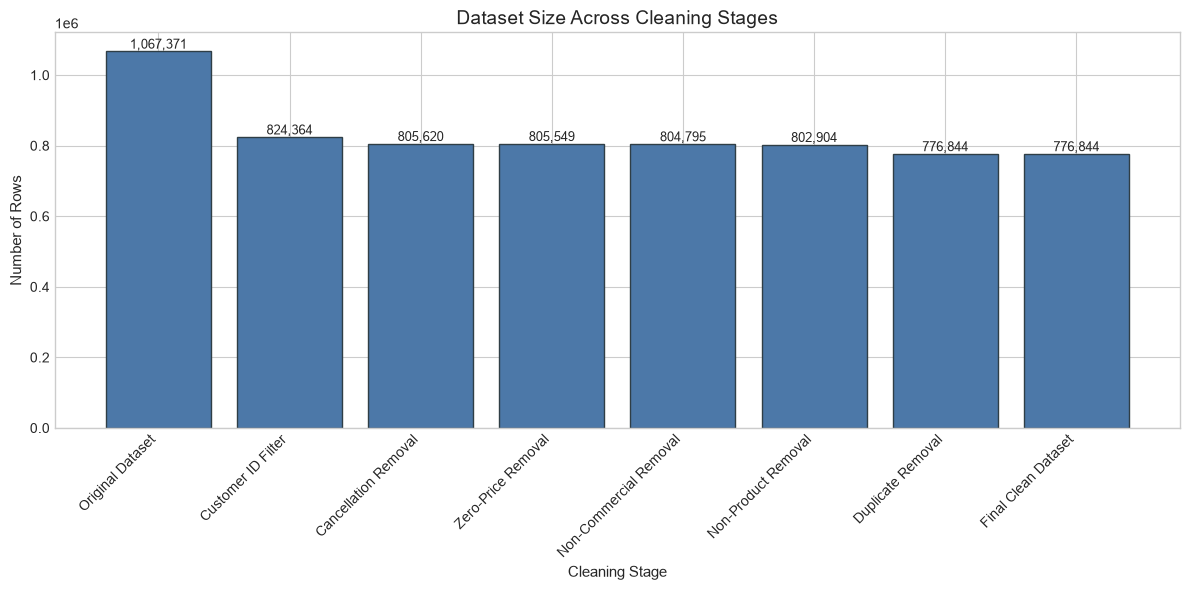

In [51]:
# Dataset size across cleaning stages

cleaning_stages = [
    "Original Dataset",
    "Customer ID Filter",
    "Cancellation Removal",
    "Zero-Price Removal",
    "Non-Commercial Removal",
    "Non-Product Removal",
    "Duplicate Removal",
    "Final Clean Dataset"
]

row_counts = [
    1067371,
    824364,
    805620,
    805549,
    804795,
    802904,
    776844,
    776844
]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    cleaning_stages,
    row_counts,
    color=COLORS["primary"],
    edgecolor=COLORS["dark"]
)

plt.title("Dataset Size Across Cleaning Stages")
plt.xlabel("Cleaning Stage")
plt.ylabel("Number of Rows")

plt.xticks(rotation=45, ha="right")

# Add row counts above each bar
for bar, count in zip(bars, row_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    plots_dir / "01_cleaning_dataset_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The dataset decreased from **1,067,371 original transaction records** to **776,844 cleaned records**.

The largest reduction occurred when transactions without a known `Customer ID` were removed. This was necessary because the project requires customer-level behavioral histories.

Cancellation transactions were then removed because they represent returns or cancellations rather than normal purchases. Zero-price transactions, non-commercial records, non-product transactions, and exact duplicate records were subsequently removed to improve the reliability of customer purchasing behavior measures.

The final dataset contains **776,844 valid transaction records**, with no missing customer IDs, negative or zero quantities, negative or zero prices, or exact duplicate rows.

### Quantity Distribution After Cleaning

A histogram is used to visualize the distribution of transaction quantities after the cleaning process. This helps verify that cancellation transactions and invalid quantities have been removed and shows the overall distribution of quantities in the final transaction-level dataset.

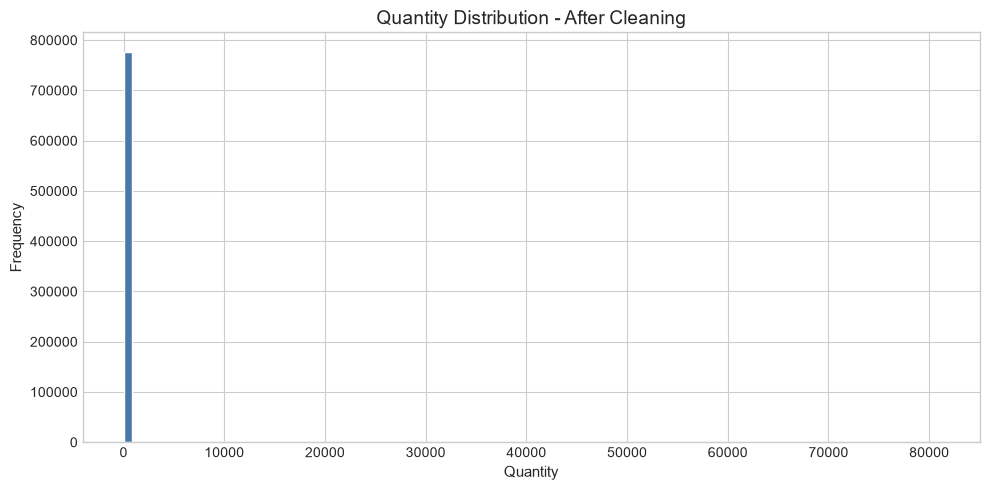

In [52]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["Quantity"].dropna(),
    bins=100,
    color=COLORS["primary"],
    edgecolor="white"
)

plt.title("Quantity Distribution - After Cleaning")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    plots_dir / "02_quantity_distribution_after_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
After cleaning, all transaction quantities are positive because cancellation transactions with negative quantities were removed. The distribution is strongly right-skewed, indicating that most transactions involve relatively small quantities, while a smaller number of transactions contain substantially larger quantities.

In [53]:
clean_df = purchase_df[
    purchase_df["Price"] > 0
].copy()

### Price Distribution After Cleaning

A histogram is used to examine the distribution of transaction prices after removing zero-price and negative-price transactions. This visualization verifies that the final dataset contains only positive transaction prices and helps identify the overall price distribution and extreme values.

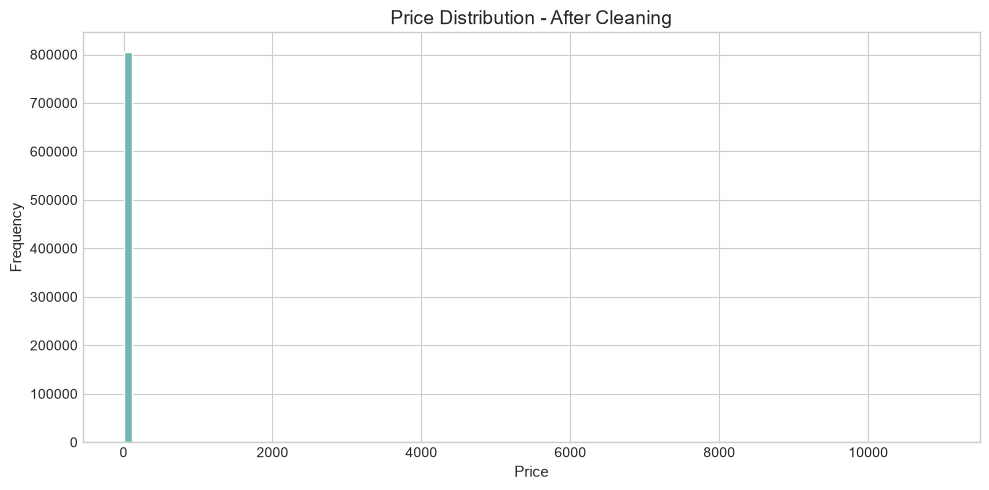

In [54]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["Price"].dropna(),
    bins=100,
    color=COLORS["secondary"],
    edgecolor="white"
)

plt.title("Price Distribution - After Cleaning")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    plots_dir / "03_price_distribution_after_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The cleaned dataset contains only positive prices, confirming that zero-price and negative-price transactions were successfully removed. The distribution remains right-skewed, with most products having relatively low prices and a smaller number of transactions having substantially higher prices.

### Quantity Before vs After Cleaning

A boxplot is used to compare transaction quantities before and after cleaning. Boxplots are particularly suitable for this comparison because the Quantity variable contains extreme values. The visualization helps show how removing cancellation transactions affected the distribution and eliminated invalid negative quantities.

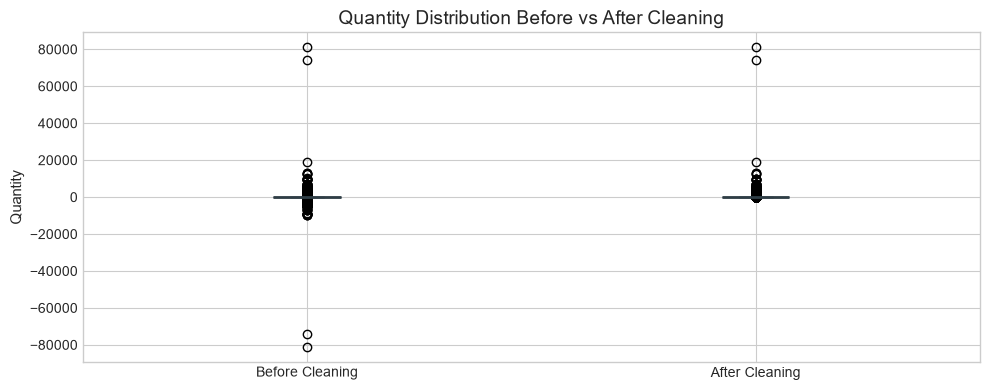

In [55]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    [
        df["Quantity"].dropna(),
        clean_df["Quantity"].dropna()
    ],
    tick_labels=["Before Cleaning", "After Cleaning"],
    patch_artist=True,
    boxprops=dict(
        facecolor=COLORS["secondary"],
        color=COLORS["dark"]
    ),
    medianprops=dict(
        color=COLORS["dark"],
        linewidth=2
    ),
    whiskerprops=dict(
        color=COLORS["dark"]
    ),
    capprops=dict(
        color=COLORS["dark"]
    )
)

plt.title("Quantity Distribution Before vs After Cleaning")
plt.ylabel("Quantity")

plt.tight_layout()

plt.savefig(
    plots_dir / "04_quantity_before_vs_after_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The comparison shows a clear change in the Quantity distribution after cleaning. Before cleaning, the data contain extreme negative values caused by cancellation transactions. After removing cancellations, the distribution contains only positive purchase quantities, making the variable more appropriate for customer behavioral analysis.

### Price Before vs After Cleaning

A boxplot is used to compare transaction prices before and after cleaning. This allows the effect of removing zero and negative prices to be examined while also showing the presence of extreme price values in the dataset.

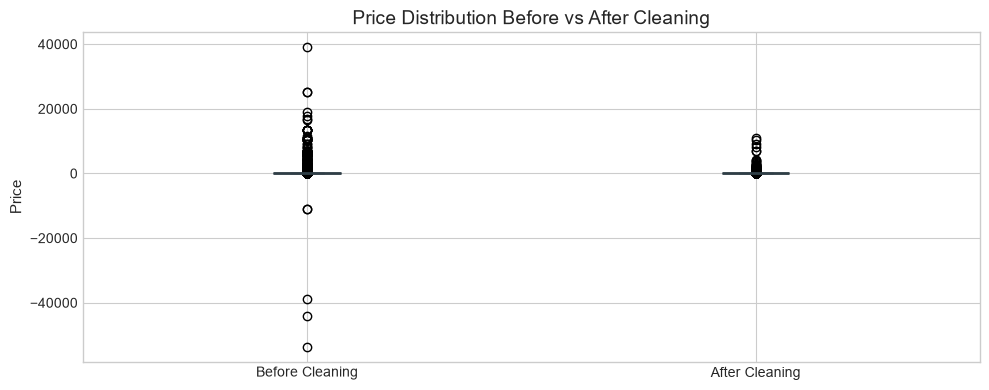

In [56]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    [
        df["Price"].dropna(),
        clean_df["Price"].dropna()
    ],
    tick_labels=["Before Cleaning", "After Cleaning"],
    patch_artist=True,
    boxprops=dict(
        facecolor=COLORS["secondary"],
        color=COLORS["dark"]
    ),
    medianprops=dict(
        color=COLORS["dark"],
        linewidth=2
    ),
    whiskerprops=dict(
        color=COLORS["dark"]
    ),
    capprops=dict(
        color=COLORS["dark"]
    )
)

plt.title("Price Distribution Before vs After Cleaning")
plt.ylabel("Price")

plt.tight_layout()

plt.savefig(
    plots_dir / "05_price_before_vs_after_cleaning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The cleaned price distribution no longer contains zero or negative transaction prices. The central distribution remains similar, while invalid price values have been removed. Extreme positive values are still present because they represent valid observed prices rather than invalid records.

### Observations Removed by Cleaning Step

A bar chart is used to summarize the number of observations removed at each major cleaning step. This provides a clear overview of the impact of the cleaning process and helps document how the raw dataset was reduced to the final transaction-level dataset.

In [57]:
removed_counts = {
    "Missing Customer ID": len(df) - len(customer_df),
    "Cancellations": len(customer_df) - len(purchase_df),
    "Zero Price": len(purchase_df) - len(clean_df) + 754 + 1891 + 26060,
    "Non-commercial": 754,
    "Non-product": 1891,
    "Exact Duplicates": 26060
}

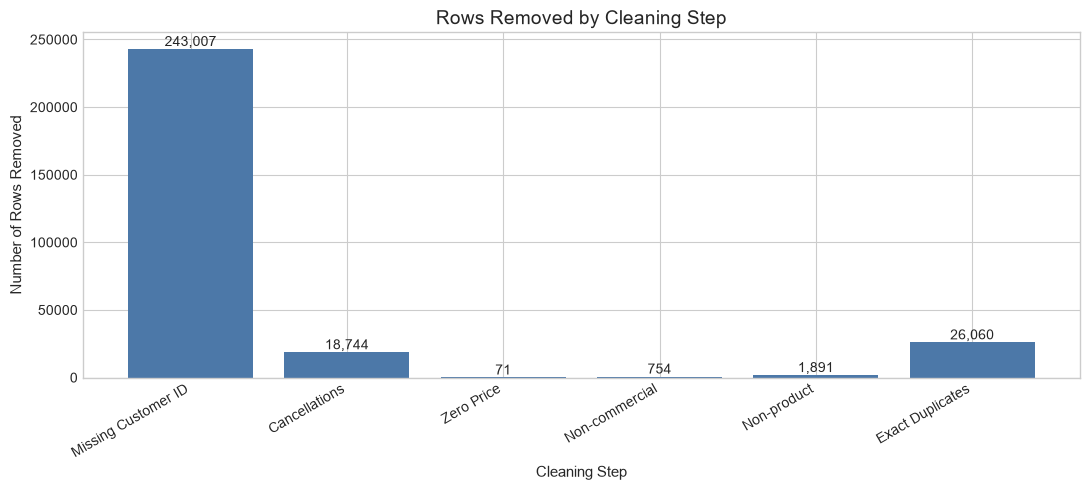

In [59]:
removed_counts = {
    "Missing Customer ID": 243007,
    "Cancellations": 18744,
    "Zero Price": 71,
    "Non-commercial": 754,
    "Non-product": 1891,
    "Exact Duplicates": 26060
}

plt.figure(figsize=(11, 5))

bars = plt.bar(
    removed_counts.keys(),
    removed_counts.values(),
    color=COLORS["primary"]
)

plt.title("Rows Removed by Cleaning Step")
plt.xlabel("Cleaning Step")
plt.ylabel("Number of Rows Removed")

plt.xticks(rotation=30, ha="right")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    plots_dir / "06_rows_removed_by_cleaning_step.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

**Interpretation:**  
The largest reduction comes from removing transactions without a Customer ID because customer-level behavioral analysis requires identifiable customers. Cancellation transactions and exact duplicate records account for additional substantial reductions. Zero-price and non-commercial transactions represent relatively small portions of the dataset. Overall, the cleaning process removes records that cannot reliably represent normal customer purchasing behavior while preserving valid purchase transactions.